---
# Spatial Demixing - Heterogeneous RNN
---

## Imports

In [57]:
# Standard library
import os, re, glob, time, gc, copy, tempfile, uuid, pickle, json, socket, sys
from tqdm import tqdm

# Core scientific stack
import numpy as np
import numba as nb
import pandas as pd
import torch
import math
from math import gamma
from scipy.stats import gamma as gamma_dist
import scipy.signal as signal
from statsmodels.tsa.stattools import acf
from scipy.special import gammaln

# Parallelization
from joblib import Parallel, delayed

# Plotting
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Scientific / ML
from scipy.integrate import solve_ivp, simpson
from scipy.signal import correlate
from numpy.polynomial.hermite import hermgauss
from numpy.linalg import eigh
from sklearn.linear_model import Ridge, LinearRegression
from scipy.signal import welch, get_window
from scipy.optimize import root_scalar, fsolve
from scipy.interpolate import griddata

## Plotting

In [33]:
color_list = ["#000000D9", "#2F43B1", "#B31010", "#FFA500", "#279B27"]

my_palettes = {'1':['#B3D69B', '#455D51', '#D8C27A', '#42AD70', '#284229', '#93CB5B'],
               '2':['#B28CF0', '#F6A3B1', '#8CCCF0', '#F6BB37', '#F3B3B4', '#36B7D2'],
               '3':['#29B4B0', '#F6753C', '#3CAF71'],
               '4':['#EF5840', "#679189", '#6EB0C6'],
               '5':['#4D7B7A', '#9B83C5', '#B2ACA7'],
               '6':['#C46CE8', '#1A63E0', '#6EE4D6'],
               '7':['#F04C45', '#FAD25A', '#F08FB5'],
               '8':['#E14E2D', '#EBAF29', '#498DC4'],
               '9':['#6B8BD4', '#FD5A40', '#45742D'],
               '10':['#D64444', '#FFBEA8', "#43A4C4", '#2D6B8C'],
               }

def plot_dynamics(x, t=None, dt=0.1, n_plot=10, N=None, title=None, cmap='Blues', label=None):
    '''
    Plot dynamics of the RNN (subset of neuron trajectories over time)
    '''
    time_steps = x.shape[1]
    N = x.shape[0]

    # Build time axis if not provided
    if t is None: 
        t = np.arange(0, int(time_steps * dt), dt)

    # Select random neuron indices to display
    random_indices = np.random.choice(N, size=n_plot, replace=False)
    selected_trajectories = x[random_indices, :]

    # Choose colors from a seaborn palette
    colors = sns.color_palette(cmap, n_plot)

    # Plot trajectories
    for i in range(n_plot):
        plt.plot(t, selected_trajectories[i, :], lw=1.5, color=colors[i], label=label if i == 0 else None)

    # Optional title
    if title:
        plt.title(title)
    
    plt.xlabel('Time (ms)')
    plt.ylabel('x(t)')

    # Set y-limits based on plotted traces
    ymin = np.round(np.min(selected_trajectories), 1)
    ymax = np.round(np.max(selected_trajectories), 1)
    plt.ylim(ymin, ymax)


def plot_acf(C, time_lags, label=None, color='C0'):
    '''
    Plot the mean autocorrelation function (ACF) with standard deviation
    '''
    C = C.T
    mean_acf = np.mean(C, axis=1)
    sig_acf = np.sqrt(np.var(C, axis=1))
    
    plt.plot(time_lags, mean_acf, lw=1.5, label=label, color=color, zorder=0)
    plt.fill_between(time_lags, mean_acf - sig_acf, mean_acf + sig_acf, color=color, alpha=0.3, label='std')
    
    plt.title('ACF', fontsize=15)
    plt.xlabel(r'$\tau$', fontsize=13)
    plt.ylabel(r'C($\tau$)', fontsize=13)
    plt.legend(frameon=False, fontsize=12)

    # Clean axis spines
    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)


def plot_theoretical_degree_distribution(model, bins=100, k_grid_size=2000, k_max_plot=None):
    '''
    Plot the theoretical degree distribution associated with the chosen model distribution
    '''
    dist = model.distribution
    N = int(model.N)

    # Poisson degree distribution
    if dist == "poisson":
        lam = float(model.K)
        kmax = int(np.ceil(lam + 8*np.sqrt(max(lam, 1e-9)))) if k_max_plot is None else int(k_max_plot)
        k = np.arange(0, kmax + 1, dtype=np.int64)
        logpmf = -lam + k*np.log(max(lam, 1e-300)) - gammaln(k + 1.0)
        pmf = np.exp(logpmf)
        pmf = pmf / pmf.sum()

        plt.plot(k, pmf, lw=2)
        return k, pmf

    # Log-normal degree distribution (continuous approximation)
    if dist == "log_normal":
        mu = float(model.mu_ln)
        sig = float(model.sig_ln)
        if k_max_plot is None:
            k_hi = float(np.exp(mu + 4*sig))
        else:
            k_hi = float(k_max_plot)
        k_lo = max(1e-6, float(np.exp(mu - 4*sig)))
        k = np.logspace(np.log10(k_lo), np.log10(k_hi), k_grid_size)

        pdf = (1.0/(k*sig*np.sqrt(2*np.pi))) * np.exp(-(np.log(k)-mu)**2/(2*sig**2))
        area = np.trapz(pdf, k)
        if area > 0:
            pdf = pdf / area
        plt.plot(k, pdf, lw=2)
        return k, pdf

    # Power-law degree distribution
    if dist == "power_law":
        alpha = float(model.alpha)
        k_min = float(model.k_min)
        k_max = float(model.k_max if k_max_plot is None else k_max_plot)

        k = np.logspace(np.log10(k_min), np.log10(k_max), k_grid_size)
        C = (1.0 - alpha) / (k_max**(1.0 - alpha) - k_min**(1.0 - alpha))
        pdf = C * k**(-alpha)

        area = np.trapz(pdf, k)
        if area > 0:
            pdf = pdf / area
        
        plt.plot(k, pdf, lw=2)
        return k, pdf

    # Fully connected case (all nodes have degree N)
    if dist == "full":
        k = np.array([N], dtype=np.int64)
        pmf = np.array([1.0], dtype=np.float64)

        plt.stem(k, pmf, use_line_collection=True) # type: ignore
        return k, pmf

    raise ValueError(f"Unsupported distribution type: {dist}")

## RNN

In [37]:
# Map activation name to integer code
ACT_MAP2 = {"tanh": 0, "linear": 1, "logistic": 2}

# Activation function used during simulation
@torch.no_grad()
def _phi_torch2(x: torch.Tensor, act_code: int):
    if act_code == 0:
        return torch.tanh(x)
    if act_code == 1:
        return x
    return torch.sigmoid(x)

# Ensure array is torch float64 tensor on CPU
@torch.no_grad()
def _ensure_torch64_cpu(a, shape=None):
    if a is None:
        return None
    if isinstance(a, np.ndarray):
        t = torch.from_numpy(a).to(dtype=torch.float64, device="cpu")
    else:
        t = torch.as_tensor(a, dtype=torch.float64, device="cpu")
    if shape is not None and tuple(t.shape) != tuple(shape):
        raise ValueError(f"array must have shape {shape}, got {tuple(t.shape)}")
    return t

# Streaming RNN simulation to reduce GPU memory usage
# Optional inputs:
#   eta : neuron-specific input with shape (steps, N)
#   z   : global time-dependent input with shape (steps,)
@torch.no_grad()
def _simulate_rnn_degree_streaming(act_code, W, steps, dt, tau_x, k_x, x0,
                                  eta=None, z=None,
                                  chunk_steps: int = 100000,
                                  out_target: str = "cpu",
                                  out_memmap_path: str | None = None,
                                  out_dtype=np.float64):
    device = W.device
    N = W.shape[0]

    # Optional external inputs (kept on CPU)
    eta_cpu = _ensure_torch64_cpu(eta, (steps, N)) if eta is not None else None
    z_cpu = _ensure_torch64_cpu(z, (steps,)) if z is not None else None

    # Allocate output array
    if out_target == "cpu" and out_memmap_path is None:
        out_host = np.empty((steps, N), dtype=out_dtype)
    else:
        if out_memmap_path is None:
            raise ValueError("Specify out_memmap_path for memmap on disk.")
        out_host = np.memmap(out_memmap_path, mode="w+", dtype=out_dtype, shape=(steps, N))

    # Initial condition
    cur = torch.as_tensor(x0, dtype=torch.float64, device=device)
    out_host[0, :] = cur.detach().cpu().numpy()

    inv_tau = 1.0 / float(tau_x)
    kk = float(k_x)
    dtv = float(dt)

    t_global = 1
    while t_global < steps:
        t_end = min(t_global + chunk_steps, steps)
        blk_len = t_end - t_global

        # Transfer current input blocks to device
        eta_blk = eta_cpu[t_global:t_end].to(device, non_blocking=True) if eta_cpu is not None else None
        z_blk = z_cpu[t_global:t_end].to(device, non_blocking=True) if z_cpu is not None else None

        block_gpu = torch.empty((blk_len, N), dtype=torch.float64, device=device)
        for k in range(blk_len):

            # Deterministic RNN drift
            drift = inv_tau * (-kk * cur + W @ _phi_torch2(cur, act_code))

            # Add neuron-wise input
            if eta_blk is not None:
                drift = drift + eta_blk[k] * inv_tau

            # Add global input
            if z_blk is not None:
                drift = drift + z_blk[k] * inv_tau
                print('Accounting also for z input')

            cur = cur + drift * dtv
            block_gpu[k] = cur

        # Move block back to CPU
        block_cpu = block_gpu.to("cpu", non_blocking=True)
        if device.type == "cuda":
            torch.cuda.synchronize(device)
        out_host[t_global:t_end, :] = block_cpu.numpy()
        t_global = t_end

    return out_host

# Recurrent neural network model
class RNN_model:
    # Initialize model parameters and computation device
    def __init__(self, mu=0, g=0.5, set_selfcoupling=False, s=0.0, gamma=0, N=100, T=500, dt=None,
                 J=None, A=None, tau_x=1.0, k_x=1.0, tau_p=1.0, p=0, K=1,
                 k_min=1, k_max=300, alpha=1, mu_ln=3, sig_ln=1,
                 activation="tanh", distribution="poisson",
                 device=None):
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device(device)
        self.set_parameters(mu=mu, g=g, set_selfcoupling=set_selfcoupling, s=s, gamma=gamma,
                            N=N, T=T, dt=dt, J=J, A=A, tau_x=tau_x, k_x=k_x, tau_p=tau_p, p=p, K=K,
                            k_min=k_min, k_max=k_max, alpha=alpha, mu_ln=mu_ln, sig_ln=sig_ln,
                            activation=activation, distribution=distribution)

    # Update model parameters and construct connectivity matrices
    def set_parameters(self, mu=None, g=None, set_selfcoupling=None, s=None, gamma=None, N=None, T=None, dt=None,
                       J=None, A=None, tau_x=None, k_x=None, tau_p=None, p=None, K=None,
                       k_min=None, k_max=None, alpha=None, mu_ln=None, sig_ln=None,
                       activation=None, distribution=None):
        if mu is not None: self.mu = float(mu)
        if g is not None: self.g = float(g)
        if set_selfcoupling is not None: self.set_selfcoupling = bool(set_selfcoupling)
        if s is not None: self.s = float(s)
        if gamma is not None: self.gamma = float(gamma)
        if N is not None: self.N = int(N)
        if T is not None: self.T = float(T)
        if dt is not None: self.dt = float(dt)
        if tau_x is not None: self.tau_x = float(tau_x)
        if k_x is not None: self.k_x = float(k_x)
        if tau_p is not None: self.tau_p = float(tau_p)
        if p is not None: self.p = float(p)
        if activation is not None: self.activation = str(activation)
        if distribution is not None: self.distribution = str(distribution)
        if k_min is not None: self.k_min = float(k_min)
        if k_max is not None: self.k_max = float(k_max)
        if alpha is not None: self.alpha = float(alpha)
        if mu_ln is not None: self.mu_ln = float(mu_ln)
        if sig_ln is not None: self.sig_ln = float(sig_ln)

        if K is not None:
            if self.distribution == "poisson":
                self.K = float(K)
            elif self.distribution == "power_law":
                _, mean, _ = self.g_critical_power_law()
                self.K = float(mean)
            elif self.distribution == "log_normal":
                self.K = float(np.exp(self.mu_ln + (self.sig_ln ** 2) / 2))
            elif self.distribution == "full":
                self.K = float(self.N)
            else:
                raise ValueError("Unsupported distribution type")

        self.A = self.sample_adjacency_matrix() if A is None else self._ensure_bin_adj(A)
        self.K_eff = float(torch.sum(self.A, dim=1).double().mean().item())

        if J is None:
            if self.gamma == 0:
                self.J = torch.randn((self.N, self.N), dtype=torch.float64, device=self.device) * (self.g / (self.K_eff ** 0.5))
            else:
                self.J = self.sample_interaction_matrix()
        else:
            self.J = self._ensure_torch64(J)

        self.W = self.J * self.A
        if self.set_selfcoupling:
            idx = torch.arange(self.N, device=self.device)
            self.W[idx, idx] = float(self.s)

        if not hasattr(self, "dt") or self.dt is None:
            raise ValueError("dt must be provided for GPU simulation.")
        self.steps = int(self.T / self.dt)

    # Convert input to torch float64 tensor on model device
    def _ensure_torch64(self, x):
        if isinstance(x, np.ndarray):
            return torch.from_numpy(x).to(dtype=torch.float64, device=self.device)
        return torch.as_tensor(x, dtype=torch.float64, device=self.device)

    # Ensure adjacency matrix is binary and symmetric
    def _ensure_bin_adj(self, A):
        t = self._ensure_torch64(A)
        if t.shape != (self.N, self.N):
            raise ValueError(f"A must have shape ({self.N}, {self.N})")
        t = (t != 0).to(dtype=torch.float64)
        t = torch.triu(t, diagonal=1)
        t = t + t.T
        return t

    # Compute critical coupling for power-law degree distribution
    def g_critical_power_law(self):
        kmin = float(self.k_min)
        kmax = float(self.k_max)
        a = float(self.alpha)
        norm = (1 - a) / (kmax ** (1 - a) - kmin ** (1 - a))
        mean = norm * (kmax ** (2 - a) - kmin ** (2 - a)) / (2 - a)
        second_moment = norm * (kmax ** (3 - a) - kmin ** (3 - a)) / (3 - a)
        g_crit = (mean ** 2 / second_moment) ** 0.5
        return g_crit, mean, second_moment

    # Generate degree sequence based on specified distribution
    def generate_degree_sequence(self):
        N = self.N
        dev = self.device
        if self.distribution == "poisson":
            k = torch.poisson(torch.full((N,), float(self.K), dtype=torch.float64, device=dev))
        elif self.distribution == "power_law":
            u = torch.rand((N,), dtype=torch.float64, device=dev)
            kmin = float(self.k_min)
            kmax = float(self.k_max)
            a = float(self.alpha)
            k = (kmin ** (1 - a) + u * (kmax ** (1 - a) - kmin ** (1 - a))) ** (1 / (1 - a))
        elif self.distribution == "log_normal":
            d = torch.distributions.LogNormal(loc=torch.tensor(float(self.mu_ln), dtype=torch.float64, device=dev),
                                              scale=torch.tensor(float(self.sig_ln), dtype=torch.float64, device=dev))
            k = d.sample((N,))
        elif self.distribution == "full":
            k = torch.ones((N,), dtype=torch.float64, device=dev) * float(N)
        else:
            raise ValueError("Unsupported distribution type")
        return k

    # Compute connection probabilities based on degree sequence
    def evaluate_p(self, k):
        return torch.outer(k, k) / (float(self.N) * float(self.K))

    # Sample adjacency matrix based on degree sequence and connection probabilities
    def sample_adjacency_matrix(self):
        k = self.generate_degree_sequence()
        p = self.evaluate_p(k)
        p = torch.clamp(p, 0.0, 1.0)
        U = torch.rand((self.N, self.N), dtype=torch.float64, device=self.device)
        A = (U < p).to(dtype=torch.float64)
        A = torch.triu(A, diagonal=1)
        A = A + A.T
        return A

    # Sample interaction matrix with specified correlation structure
    def sample_interaction_matrix(self):
        z1 = torch.randn((self.N, self.N), dtype=torch.float64, device=self.device)
        z2 = torch.randn((self.N, self.N), dtype=torch.float64, device=self.device)

        upper = (self.mu / self.N) + (self.g / (self.K_eff ** 0.5)) * z1
        lower = (self.mu / self.N) + (self.g / (self.K_eff ** 0.5)) * (self.gamma * z1 + (1 - self.gamma ** 2) ** 0.5 * z2)

        mat = torch.zeros((self.N, self.N), dtype=torch.float64, device=self.device)
        triu = torch.triu_indices(self.N, self.N, offset=1, device=self.device)
        i = triu[0]
        j = triu[1]
        mat[i, j] = upper[i, j]
        mat[j, i] = lower[i, j]
        return mat

    # Simulate RNN activity and return activity and time vector
    @torch.no_grad()
    def simulate_RNN(self, x0=None, eta=None, z=None, stream=True, chunk_steps=2000,
                     out_target="cpu", out_memmap_path=None, out_dtype=np.float64):
        if self.activation not in ACT_MAP2:
            raise ValueError(f"activation must be in {list(ACT_MAP2.keys())}")
        act_code = ACT_MAP2[self.activation]

        if x0 is None:
            x0_t = torch.randn((self.N,), dtype=torch.float64, device=self.device)
        else:
            x0_t = torch.as_tensor(x0, dtype=torch.float64, device=self.device)
            if x0_t.shape != (self.N,):
                raise ValueError(f"x0 must have shape ({self.N},)")

        # Optional inputs (provided on CPU)
        if eta is not None:
            eta_cpu = _ensure_torch64_cpu(eta, (self.steps, self.N))
        else:
            eta_cpu = None

        if z is not None:
            z_cpu = _ensure_torch64_cpu(z, (self.steps,))
        else:
            z_cpu = None

        if stream:
            X_host = _simulate_rnn_degree_streaming(
                act_code=act_code, W=self.W, steps=self.steps, dt=self.dt,
                tau_x=self.tau_x, k_x=self.k_x, x0=x0_t,
                eta=eta_cpu, z=z_cpu,
                chunk_steps=chunk_steps, out_target=out_target,
                out_memmap_path=out_memmap_path, out_dtype=out_dtype
            )
        else:
            steps = self.steps
            N = self.N
            dtv = float(self.dt)
            inv_tau = 1.0 / float(self.tau_x)
            kk = float(self.k_x)

            eta_dev = eta_cpu.to(self.device) if eta_cpu is not None else None
            z_dev = z_cpu.to(self.device) if z_cpu is not None else None

            act = torch.empty((steps, N), dtype=torch.float64, device=self.device)
            act[0] = x0_t
            for t in range(1, steps):
                cur = act[t - 1]
                drift = inv_tau * (-kk * cur + self.W @ _phi_torch2(cur, act_code))
                if eta_dev is not None:
                    drift = drift + eta_dev[t] * inv_tau
                if z_dev is not None:
                    drift = drift + z_dev[t] * inv_tau
                    print('Accounting also for z input')
                act[t] = cur + drift * dtv
            X_host = act.to("cpu").numpy()

        t = (torch.arange(self.steps, dtype=torch.float64, device=self.device) * self.dt).cpu().numpy()
        return X_host.T, t

## Utils

In [38]:
# Equation used to solve for k_min in the power-law case (given target mean degree K)
def equation_kmin(k_min, alpha, K, k_max):
    if k_min >= k_max:
        return np.inf
    C = (1 - alpha) / (k_max**(1 - alpha) - k_min**(1 - alpha))
    integral_part = (k_max**(2 - alpha) - k_min**(2 - alpha)) / (2 - alpha)
    return C * integral_part - K


# Solve for k_min numerically so that the power-law distribution has mean degree K
def evaluate_kmin(K, k_max, alpha):
    k_min_0 = 1.0
    k_min_sol = fsolve(equation_kmin, k_min_0, args=(alpha, K, k_max))
    return float(k_min_sol[0])


# Build a model and (if needed) resample until K_eff matches K within tolerance
def find_valid_model_cuda(tol=1.0, max_attempts=None, strict=False, **model_kwargs):
    if "dt" not in model_kwargs or model_kwargs["dt"] is None:
        raise ValueError("dt must be provided (GPU simulator is discrete-time Euler).")

    N = int(model_kwargs.get("N", 1000))

    # Default number of attempts depends on network size
    if max_attempts is None:
        max_attempts = 40 if N < 1500 else 20 if N < 3500 else 10 if N < 5500 else 5
    max_attempts = max(1, int(max_attempts))

    dist = model_kwargs.get("distribution", "poisson")

    # Pre-compute distribution-specific parameters before building the model
    if dist == "power_law":
        model_kwargs["k_min"] = evaluate_kmin(model_kwargs["K"], model_kwargs["k_max"], model_kwargs["alpha"])
    elif dist == "log_normal":
        model_kwargs["K"] = float(np.exp(model_kwargs["mu_ln"] + model_kwargs["sig_ln"]**2 / 2))
    elif dist in ["full", "poisson"]:
        return RNN_model(**model_kwargs)
    else:
        raise ValueError("Unsupported distribution type")

    best_model = None
    best_err = float("inf")

    # Try multiple random draws and keep the one closest to the target
    for _ in range(max_attempts):
        model = RNN_model(**model_kwargs)
        err = abs(float(model.K) - float(model.K_eff))
        if err < best_err:
            best_err = err
            best_model = model
        if err <= tol:
            return model

    if best_model is None:
        raise RuntimeError("Internal error: no model was created.")

    # Optionally enforce strict tolerance
    if strict and best_err > tol:
        raise RuntimeError(f"Could not meet tol={tol}. Best error={best_err:.4g} after {max_attempts} attempts.")

    return best_model


# Compute empirical correlation between J_ij and J_ji across all pairs (i,j) (gamma)
def empirical_correlation(J):
    N = J.shape[0]
    
    i, j = np.triu_indices(N, k=1)  
    J_ij = J[i, j]
    J_ji = J[j, i]
    correlation = np.corrcoef(J_ij, J_ji)[0, 1]
    
    return correlation

# Compute autocorrelation function (ACF) after removing initial transient
def compute_acf(sim, T_start, dt, maxlags=None):

    sim = np.asarray(sim)
    N, T = sim.shape

    # Remove burn-in period
    T0 = int(T_start / dt)

    # Default maximum lag
    if maxlags is None:
        maxlags = int(100 / dt)

    # Subtract mean activity
    x = sim[:, T0:] - sim[:, T0:].mean(axis=1, keepdims=True)

    acf_list = []
    min_len = None

    # Compute ACF for each neuron
    for i in range(N):
        a = acf(x[i], nlags=maxlags-1, fft=True, adjusted=True)
        acf_list.append(a)

        # Track shortest valid length
        if min_len is None or len(a) < min_len:
            min_len = len(a)

    # Make all ACFs same length
    L = min(min_len, maxlags)  # type: ignore
    acfs = np.zeros((N, L))

    for i in range(N):
        acfs[i] = acf_list[i][:L]

    # Time lags
    lags = np.arange(L) * dt

    return acfs, lags


# Generate broadband input signal (time expressed in ms)
def generate_broadband_input_ms(steps, dt_ms, N, freqs, amplitude=0.5, rng=None):
    '''
    Generate broadband input in ms units
    '''

    if rng is None:
        rng = np.random.default_rng()

    # Convert timestep to seconds
    dt_s = dt_ms / 1000.0
    t_s  = np.arange(steps) * dt_s

    # Precompute sine and cosine contributions
    freqs = np.asarray(freqs, dtype=np.float64)
    phases_mat = 2.0 * np.pi * freqs[:, None] * t_s[None, :]
    sin_mat = np.sin(phases_mat)
    cos_mat = np.cos(phases_mat)

    S_t = np.sum(sin_mat, axis=0)
    C_t = np.sum(cos_mat, axis=0)

    # Assign one random phase per neuron
    theta     = rng.uniform(0.0, 2.0 * np.pi, size=N)
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)

    # Build input matrix
    I = amplitude * (
        cos_theta[None, :] * S_t[:, None]
        + sin_theta[None, :] * C_t[:, None]
    )

    return I


# Compute population-averaged power spectral density
def compute_population_psd(X, dt_s):
    """
    Population-averaged power spectral density
    """

    N_pop, T = X.shape
    fs = 1.0 / dt_s

    # Remove mean activity
    Xc = X - X.mean(axis=1, keepdims=True)

    # Apply Hann window
    window = np.hanning(T)
    Xw = Xc * window[None, :]

    # Fourier transform
    X_fft = np.fft.rfft(Xw, axis=1)
    freqs = np.fft.rfftfreq(T, d=dt_s)

    # Normalize power
    U = np.sum(window**2)
    psd = (np.abs(X_fft)**2) / (fs * U)

    # One-sided spectrum correction
    if T % 2 == 0:
        psd[:, 1:-1] *= 2.0
    else:
        psd[:, 1:] *= 2.0

    # Average across neurons
    psd_mean = psd.mean(axis=0)

    return freqs, psd_mean


# Generate random frequencies with minimum separation
def generate_random_freqs(M=11, f_min=1.0, f_max=200.0,
                          min_sep=8.0, seed=123):

    rng = np.random.default_rng(seed)
    freqs = []

    # Sample frequencies until constraints are satisfied
    while len(freqs) < M:
        f_new = rng.uniform(f_min, f_max)

        if all(abs(f_new - f_old) >= min_sep for f_old in freqs):
            freqs.append(f_new)

    return np.array(sorted(freqs))


# Generate adjacency matrix with two degree populations
def sample_two_level_adjacency(
    N=3000,
    k_low=100.0,
    k_high=1000.0,
    p_low=0.9,
    seed=0,
    dtype=np.int8
):

    # Parameter checks
    if N < 2:
        raise ValueError("N must be >= 2")
    if k_low < 0 or k_high < 0:
        raise ValueError("Degrees must be nonnegative")
    if k_low > N - 1 or k_high > N - 1:
        raise ValueError("k_low and k_high must be <= N-1")
    if p_low < 0.0 or p_low > 1.0:
        raise ValueError("p_low must be in [0,1]")

    rng = np.random.default_rng(seed)

    # Number of low-degree nodes
    n1 = int(rng.binomial(N, float(p_low)))
    n1 = max(1, min(N - 1, n1))

    # Degree sequence
    k = np.empty(N, dtype=np.float64)
    k[:n1] = float(k_low)
    k[n1:] = float(k_high)

    # Connection probability matrix
    K = float(k.mean())
    p = np.outer(k, k) / (N * K)

    np.clip(p, 0.0, 1.0, out=p)
    np.fill_diagonal(p, 0.0)

    # Sample symmetric adjacency matrix
    U = rng.random((N, N))
    A = (U < p).astype(dtype)
    A = np.triu(A, 1)
    A = A + A.T

    return A, n1

## Spatial Demixing 

In [40]:
# Generate two level adjacency matrix
A_mat, n1 = sample_two_level_adjacency(
    N=4000,
    k_low=100,
    k_high=1000,
    p_low=0.9,
    seed=1
)

# Model parameters for RNN simulation
model_kwargs = {
    "mu": 0,
    "g": 3.0,
    "set_selfcoupling": True,
    "s": 0.0,
    "gamma": 0.3,          
    "N": 4000,             
    "T": 15000,            
    "dt": 0.1,             
    "J": None,
    "A": A_mat,            
    "tau_x": 1.0,
    "k_x": 1.0,
    "tau_p": 2.5,
    "p": 0,
    "K": None,
    "k_min": 1,
    "k_max": 4000,
    "alpha": 1.5,
    "mu_ln": 3,
    "sig_ln": 1,
    "activation": "tanh",
    "distribution": None,
    "device": "cuda"       
}

model = RNN_model(**model_kwargs)

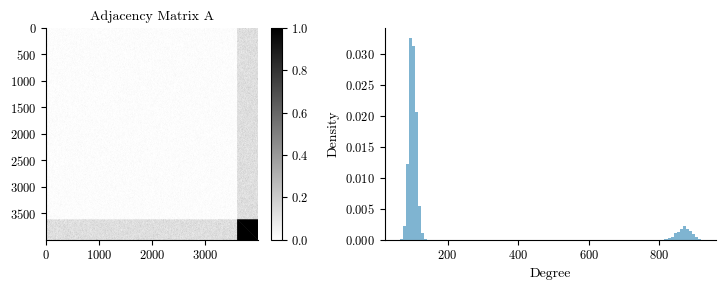

In [41]:
# Extract matrices and degree vector
A_mat = model.A.cpu().numpy()
W_mat = model.W.cpu().numpy()
degree_vect = np.sum(A_mat, axis=1)

# Create side by side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# Adjacency matrix
im = ax1.imshow(A_mat[:4000, :4000], cmap='binary')
ax1.set_title('Adjacency Matrix A')
cbar = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

# Degree distribution
ax2.hist(degree_vect, bins=100, density=True, color='C0', alpha=0.5)
ax2.set_xlabel('Degree', fontsize=10)
ax2.set_ylabel('Density', fontsize=10)

plt.tight_layout()
plt.show()

In [42]:
# Parameters for stimulus
M = 11
f_min, f_max = 1.0, 400.0
freqs_lin = np.linspace(f_min, f_max, M)

rng = np.random.default_rng(123)
jitter = rng.uniform(-1, 1, size=M) 

freqs_sin = freqs_lin + jitter
freqs_sin = np.clip(freqs_sin, f_min, f_max)
freqs_sin = np.sort(freqs_sin)

# Generate ICs
x0 = np.random.normal(0, 1, size=model.N) * 1e-1

# Generate input
start_time = time.time()
eta = generate_broadband_input_ms(model.steps, model.dt, model.N, freqs_sin, amplitude=0.5, rng=None)
print(f"Input generation time: {time.time() - start_time:.2f} seconds")

start = time.time()
x, t = model.simulate_RNN(x0=x0, eta=eta, z=None, stream=True, chunk_steps=20000)  # x is (N, steps)
end = time.time()

Input generation time: 8.16 seconds


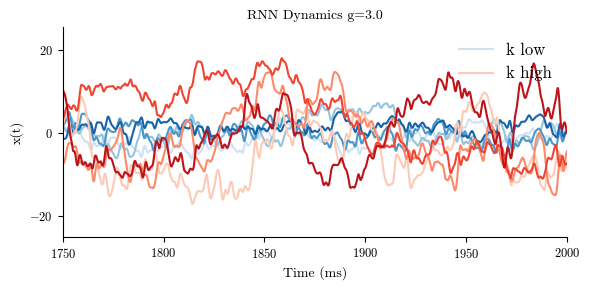

In [ ]:
# Plot dynamics of a few neurons from each group (low and high degree)
group_bound = [0, n1, model.N]

plt.figure(figsize=(6, 3))
plot_dynamics(x[:5], t=t, dt=model.dt, n_plot=4, N=model.N, title=fr'RNN Dynamics g={model.g}', cmap='Blues', label='k low')
plot_dynamics(x[n1:n1+5], t=t, dt=model.dt, n_plot=4, N=model.N, cmap='Reds', label='k high')
plt.xlabel('Time (ms)')
plt.gca().locator_params(axis='both', nbins=5)
plt.xlim(1750, 2000)
plt.legend(frameon=False, fontsize=12)
plt.show()

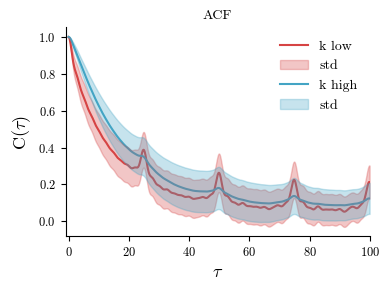

In [ ]:
# Compute and plot autocorrelation functions (ACF) for low and high degree groups
acf_x_g1, lags = compute_acf(x[group_bound[0]:group_bound[1], :], T_start=10000, dt=model.dt, maxlags=1000)
acf_x_g2, lags = compute_acf(x[group_bound[1]:group_bound[2], :], T_start=10000, dt=model.dt, maxlags=1000)

plt.figure(figsize=(4,3))
plot_acf(acf_x_g1, lags, label='k low', color=my_palette[0])
plot_acf(acf_x_g2, lags, label='k high', color=my_palette[2])
plt.title("ACF")
plt.legend(frameon=False)
plt.xlim(-1,100)
plt.show()

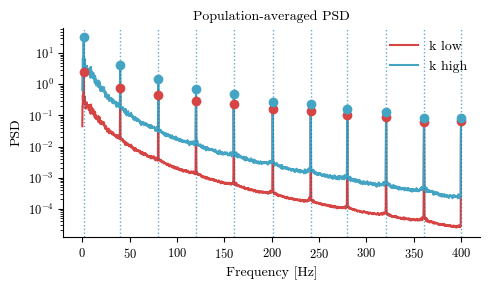

In [54]:
# Compute sampling time in seconds
dt_ms = model.dt
dt_s = dt_ms / 1000.0
fs = 1.0 / dt_s

# Remove transient activity
transient = 10000
transient_steps = int(transient / dt_ms)
r = x[:, transient_steps:]

# Select low and high degree neuron groups
g1 = slice(group_bound[0], group_bound[1])
g2 = slice(group_bound[1], group_bound[2])

# Compute population averaged PSD for the two groups
freqs, psd_g1 = compute_population_psd(r[g1], dt_s)
_, psd_g2 = compute_population_psd(r[g2], dt_s)

# Keep frequencies up to fmax
fmax = 400.0
mask = freqs <= fmax

freqs = freqs[mask]
psd_g1 = psd_g1[mask]
psd_g2 = psd_g2[mask]

# Select colors
my_palette = my_palettes['10']

# Plot PSD curves
plt.figure(figsize=(5, 3))
plt.semilogy(freqs, psd_g1, color=my_palette[0], lw=1.5, label="k low")
plt.semilogy(freqs, psd_g2, color=my_palette[2], lw=1.5, label="k high")

# Plot vertical lines at input frequencies
for f_in in freqs_sin:
    plt.axvline(f_in, linestyle=':', linewidth=1, alpha=0.6)

# Find PSD values at input frequencies
idx = np.array([np.argmin(np.abs(freqs - f)) for f in freqs_sin])
psd1_sel = psd_g1[idx]
psd2_sel = psd_g2[idx]

# Mark PSD values at input frequencies
plt.semilogy(freqs[idx], psd1_sel,
             color=my_palette[0], marker='o', ls='none', ms=6)
plt.semilogy(freqs[idx], psd2_sel,
             color=my_palette[2], marker='o', ls='none', ms=6)

# Labels and layout
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD")
plt.title("Population-averaged PSD")
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

# Simulation loop

In [56]:
# Output folder
SAVE_DIR = "/data/taffarello/demixing/demix_hetrnn"
os.makedirs(SAVE_DIR, exist_ok=True)

# Generate input frequencies
def _make_freqs(M, f_min=1.0, f_max=400.0, seed=123, jitter=1.0):
    freqs_lin = np.linspace(f_min, f_max, M)
    rng = np.random.default_rng(seed)
    freqs = freqs_lin + rng.uniform(-jitter, jitter, size=M)
    freqs = np.clip(freqs, f_min, f_max)
    return np.sort(freqs)

# Build a unique tag for saving files
def _tag(meta):
    return f"N{meta['N']}_T{int(meta['T'])}_dt{meta['dt']}_kl{meta['k_low']}_kh{meta['k_high']}_g{meta['gamma']}_M{meta['M']}_sg{meta['seed_graph']}_sf{meta['seed_freqs']}"

# Save a short dynamics plot for low and high degree groups
def save_dynamics_plot(x, t, model, out_png, group_bound=None):
    if group_bound is None:
        group_bound = [0, model.N // 2, model.N]

    plt.figure(figsize=(8, 4))

    plot_dynamics(
        x[group_bound[0]:group_bound[0] + 5],
        t=t, dt=model.dt, n_plot=4, N=model.N,
        title=fr'RNN Dynamics g={model.g}',
        cmap='Blues', label='k low'
    )

    plot_dynamics(
        x[group_bound[1]:group_bound[1] + 5],
        t=t, dt=model.dt, n_plot=4, N=model.N,
        cmap='Reds', label='k high'
    )

    plt.xlabel('Time (ms)')
    plt.gca().locator_params(axis='both', nbins=5)
    plt.xlim(1750, 2000)
    plt.legend(frameon=False, fontsize=12)
    plt.tight_layout()
    plt.savefig(out_png, dpi=400)
    plt.close()

# Sweep over parameters and save results
def run_demix_sweep(base_kwargs_template,
                    gammas=(0.0, 0.1, 0.3, 0.5),
                    low_list=(30, 60, 100),
                    high_list=(60, 100, 200, 300, 500),
                    M_list=(11, 21, 31),
                    transient_ms=7500.0,
                    acf_maxlags=750,
                    amplitude=0.5,
                    f_min=1.0, f_max=400.0,
                    jitter=1.0,
                    seed_graph0=1,
                    seed_freqs0=123,
                    chunk_steps=20000):

    N = int(base_kwargs_template["N"])
    group_bound = [0, N // 2, N]

    for gamma in gammas:
        for k_low in low_list:
            for k_high in high_list:
                if k_low >= k_high:
                    continue
                for M in M_list:

                    # Seeds for reproducibility
                    seed_graph = int(seed_graph0 + 1000 * int(round(10 * gamma)) + 10 * k_low + k_high + M)
                    seed_freqs = int(seed_freqs0 + 17 * M + 3 * k_low + 5 * k_high + int(round(100 * gamma)))

                    # Metadata for this run
                    meta = dict(
                        N=N,
                        T=float(base_kwargs_template["T"]),
                        dt=float(base_kwargs_template["dt"]),
                        mu=float(base_kwargs_template["mu"]),
                        g=float(base_kwargs_template["g"]),
                        tau_x=float(base_kwargs_template["tau_x"]),
                        k_x=float(base_kwargs_template.get("k_x", 1.0)),
                        gamma=float(gamma),
                        k_low=int(k_low),
                        k_high=int(k_high),
                        M=int(M),
                        amplitude=float(amplitude),
                        f_min=float(f_min),
                        f_max=float(f_max),
                        jitter=float(jitter),
                        transient_ms=float(transient_ms),
                        acf_maxlags=int(acf_maxlags),
                        seed_graph=int(seed_graph),
                        seed_freqs=int(seed_freqs),
                        activation=str(base_kwargs_template.get("activation", "tanh")),
                        device=str(base_kwargs_template.get("device", "cuda"))
                    )

                    tag = _tag(meta)
                    npz_path = os.path.join(SAVE_DIR, f"{tag}.npz")
                    dyn_png = os.path.join(SAVE_DIR, f"{tag}_dyn.png")

                    # Skip if already computed
                    if os.path.exists(npz_path):
                        print("skip:", os.path.basename(npz_path))
                        continue

                    print("run:", tag)

                    # Build adjacency matrix
                    A_mat = sample_two_level_adjacency(N=N, k_low=k_low, k_high=k_high, seed=seed_graph)
                    degree_vect = np.sum(A_mat, axis=1).astype(np.int32)

                    # Create model for this run
                    run_kwargs = dict(base_kwargs_template)
                    run_kwargs["gamma"] = float(gamma)
                    run_kwargs["A"] = A_mat
                    model = RNN_model(**run_kwargs)

                    # Input frequencies
                    freqs_sin = _make_freqs(M, f_min=f_min, f_max=f_max, seed=seed_freqs, jitter=jitter)

                    # Initial condition
                    x0 = np.random.default_rng(seed_graph + 999).normal(0, 1, size=model.N) * 1e-1

                    # External input (eta)
                    eta = generate_broadband_input_ms(
                        model.steps, model.dt, model.N, freqs_sin,
                        amplitude=amplitude, rng=np.random.default_rng(seed_freqs)
                    )

                    # Simulate dynamics
                    t0 = time.time()
                    x, t = model.simulate_RNN(
                        x0=x0, eta=eta, z=None,
                        stream=True, chunk_steps=chunk_steps,
                        out_target="cpu", out_memmap_path=None
                    )
                    sim_seconds = time.time() - t0

                    # Remove transient
                    dt_ms = float(model.dt)
                    dt_s = dt_ms / 1000.0
                    transient_steps = int(transient_ms / dt_ms)
                    r = x[:, transient_steps:]

                    g1 = slice(group_bound[0], group_bound[1])
                    g2 = slice(group_bound[1], group_bound[2])

                    # Compute ACF
                    acf_g1, lags = compute_acf(r[g1, :], T_start=0, dt=dt_ms, maxlags=acf_maxlags)
                    acf_g2, _    = compute_acf(r[g2, :], T_start=0, dt=dt_ms, maxlags=acf_maxlags)

                    acf_g1_mean = acf_g1.mean(axis=0)
                    acf_g2_mean = acf_g2.mean(axis=0)
                    acf_g1_sd   = acf_g1.std(axis=0)
                    acf_g2_sd   = acf_g2.std(axis=0)

                    # Compute PSD
                    freqs_psd, psd_g1 = compute_population_psd(r[g1], dt_s)
                    _,         psd_g2 = compute_population_psd(r[g2], dt_s)

                    # Compute MI at input frequencies
                    idx = np.array([np.argmin(np.abs(freqs_psd - f)) for f in freqs_sin], dtype=np.int32)
                    psdsel_g1 = psd_g1[idx]
                    psdsel_g2 = psd_g2[idx]
                    MI = (psdsel_g2 - psdsel_g1) / (psdsel_g1 + psdsel_g2 + 1e-30)

                    # Save dynamics plot
                    save_dynamics_plot(x, t, model, dyn_png, group_bound=group_bound)

                    # Save results
                    np.savez_compressed(
                        npz_path,
                        meta=json.dumps(meta),
                        degree_vect=degree_vect.astype(np.int32),
                        group_bound=np.array(group_bound, dtype=np.int32),
                        freqs_in=freqs_sin.astype(np.float64),
                        lags=lags.astype(np.float64),
                        acf_g1_mean=acf_g1_mean.astype(np.float64),
                        acf_g2_mean=acf_g2_mean.astype(np.float64),
                        acf_g1_sd=acf_g1_sd.astype(np.float64),
                        acf_g2_sd=acf_g2_sd.astype(np.float64),
                        freqs_psd=freqs_psd.astype(np.float64),
                        psd_g1=psd_g1.astype(np.float64),
                        psd_g2=psd_g2.astype(np.float64),
                        idx_in=idx.astype(np.int32),
                        psdsel_g1=psdsel_g1.astype(np.float64),
                        psdsel_g2=psdsel_g2.astype(np.float64),
                        MI=MI.astype(np.float64),
                        sim_seconds=np.float64(sim_seconds)
                    )

                    # Cleanup
                    del x, eta, model, A_mat
                    gc.collect()
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()

                    print("saved:", os.path.basename(npz_path))

In [ ]:
# Base parameters of the RNN model
model_kwargs = {
    "mu": 0,
    "g": 3.0,
    "set_selfcoupling": True,
    "s": 0.0,
    "gamma": 0.0,
    "N": 4000,
    "T": 15000,
    "dt": 0.1,
    "J": None,
    "A": None,            
    "tau_x": 1.0,
    "k_x": 1.0,
    "tau_p": 2.5,
    "p": 0,
    "K": None,
    "k_min": 1,
    "k_max": 4000,
    "alpha": 1.5,
    "mu_ln": 3,
    "sig_ln": 1,
    "activation": "tanh",
    "distribution": None,
    "device": "cuda"        
}

# Run parameter sweep for demixing experiments
run_demix_sweep(
    model_kwargs,
    gammas=(0.0, 0.1, 0.3, 0.4, 0.5),
    low_list=(30, 60, 100),
    high_list=(60, 100, 200, 500, 1000),
    M_list=(11, 21, 31),
    transient_ms=7500.0,
    acf_maxlags=750,
    amplitude=0.5,
    f_min=1.0, f_max=400.0,
    jitter=1.0,
    seed_graph0=1,
    seed_freqs0=123,
    chunk_steps=20000
)

## Panel Demixing

In [22]:
SAVE_DIR = "/data/taffarello/demixing/demix_hetrnn"

def load_all_results(save_dir=SAVE_DIR):
    files = sorted(glob.glob(os.path.join(save_dir, "*.npz")))
    out = []
    for fp in files:
        d = np.load(fp, allow_pickle=True)
        meta = json.loads(str(d["meta"]))
        out.append((meta, fp))
    return out

def select_results(index, gamma=None, k_low=None, k_high=None, M=None, N=None):
    sel = []
    for meta, fp in index:
        if gamma is not None and float(meta["gamma"]) != float(gamma): continue
        if k_low is not None and int(meta["k_low"]) != int(k_low): continue
        if k_high is not None and int(meta["k_high"]) != int(k_high): continue
        if M is not None and int(meta["M"]) != int(M): continue
        if N is not None and int(meta["N"]) != int(N): continue
        sel.append((meta, fp))
    return sel

def load_result(fp):
    d = np.load(fp, allow_pickle=True)
    meta = json.loads(str(d["meta"]))
    return meta, d

In [ ]:
# STYLE settings for plotting
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

plt.style.use('tableau-colorblind10')
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

plt.rcParams.update({
    "font.size": 10,
    "font.family": "serif",
    "font.serif": "cmr10",
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True
})

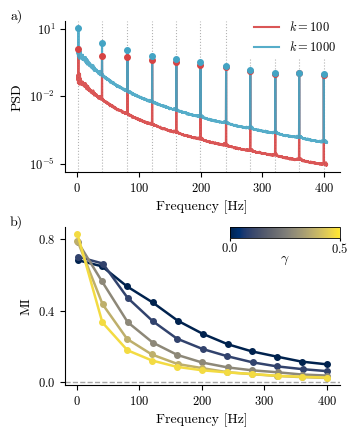

In [ ]:
# Figure size in cm
W_CM = 9
H_CM = 12

# Create figure and grid layout
fig = plt.figure(figsize=(W_CM/2.54, H_CM/2.54), constrained_layout=False)
gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.05], hspace=0.35)

ax_top = fig.add_subplot(gs[0, 0])
ax_bot = fig.add_subplot(gs[1, 0])

# Panel labels
ax_top.text(-0.2, 1.01, "a)", transform=ax_top.transAxes)
ax_bot.text(-0.2, 1.01, "b)", transform=ax_bot.transAxes)

# Load saved simulation index
index = load_all_results(SAVE_DIR)

# Select dataset for gamma = 0.3
sel = select_results(index, gamma=0.3, k_low=100, k_high=1000, M=11)
meta, d = load_result(sel[0][1])

# Extract PSD data
freqs = d["freqs_psd"]
psd_g1 = d["psd_g1"]
psd_g2 = d["psd_g2"]
freqs_in = d["freqs_in"]

# Input frequency indices
idx_in = d["idx_in"] if "idx_in" in d else np.array(
    [np.argmin(np.abs(freqs - f)) for f in freqs_in]
)

# Frequency range selection
fmax = 405.0
mask = (freqs >= 1e-3) & (freqs <= fmax)

freqs_m = freqs[mask]
psd1_m = psd_g1[mask]
psd2_m = psd_g2[mask]

# Clean valid indices
idx_in = np.asarray(idx_in, int)
idx_in = idx_in[(idx_in >= 0) & (idx_in < len(freqs))]
idx_in_m = idx_in[freqs[idx_in] <= fmax]

# Use custom palette
pal_top = my_palettes["10"]

# Plot PSD curves
ax_top.semilogy(freqs_m, psd1_m,
                color=pal_top[0], lw=1.5, alpha=0.9,
                label=r"$k=100$")
ax_top.semilogy(freqs_m, psd2_m,
                color=pal_top[2], lw=1.5, alpha=0.9,
                label=r"$k=1000$")

# Plot input frequencies
for f in freqs_in:
    ax_top.axvline(f, ls=":", lw=0.8,
                   alpha=0.6, zorder=0, color="gray")

# Mark PSD values at input frequencies
ax_top.semilogy(freqs[idx_in_m], psd_g1[idx_in_m],
                color=pal_top[0], marker="o",
                ls="none", ms=4, zorder=3)
ax_top.semilogy(freqs[idx_in_m], psd_g2[idx_in_m],
                color=pal_top[2], marker="o",
                ls="none", ms=4, zorder=3)

# Axis labels
ax_top.set_xlabel("Frequency [Hz]")
ax_top.set_ylabel("PSD")

# Custom y ticks
ax_top.set_yticks([1e1, 1e-2, 1e-5])
ax_top.set_yticklabels([r"$10^{1}$", r"$10^{-2}$", r"$10^{-5}$"])
ax_top.minorticks_off()

# Legend
leg = ax_top.legend(
    frameon=True,
    fancybox=False,
    framealpha=1.0,
    edgecolor="none",
    fontsize=9,
    loc=(0.67, 0.75),
)

# Match legend background to figure
leg.get_frame().set_facecolor(fig.get_facecolor())
leg.set_zorder(10)

# Gamma values for MI curves
gammas = np.array((0.0, 0.1, 0.3, 0.4, 0.5), dtype=float)

# Colormap for gamma
cmap = plt.get_cmap("cividis")
norm = Normalize(vmin=float(gammas.min()),
                 vmax=float(gammas.max()))
trim_max = 0.95
colors = cmap(trim_max * norm(gammas))

# Plot MI curves for different gamma
for g, col in zip(gammas, colors):

    sel = select_results(index,
                         gamma=float(g),
                         k_low=100,
                         k_high=1000,
                         M=11)

    if len(sel) == 0:
        print("missing:", g)
        continue

    meta_g, d_g = load_result(sel[0][1])
    freqs_in_g = d_g["freqs_in"]
    MI = d_g["MI"]

    ax_bot.plot(freqs_in_g, MI,
                marker="o",
                markersize=4,
                lw=1.8,
                color=col)

# Zero reference line
ax_bot.axhline(0,
               ls="--",
               lw=1,
               color="gray",
               alpha=0.7)

# Axis labels
ax_bot.set_xlabel("Frequency [Hz]")
ax_bot.set_ylabel("MI")
ax_bot.set_yticks([0.0, 0.4, 0.8])

# Create colorbar for gamma
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# Inset colorbar
cax = inset_axes(
    ax_bot,
    width="40%",
    height="7%",
    loc="upper right",
    borderpad=0
)

cbar = plt.colorbar(sm,
                    cax=cax,
                    orientation="horizontal")

# Colorbar formatting
cbar.set_label(r"$\gamma$", labelpad=-1)
cbar.set_ticks([gammas.min(), gammas.max()])
cbar.ax.tick_params(pad=1, length=2)

# Cleaner outline
cbar.outline.set_linewidth(0.6)  # type: ignore

# Show and save the figure
plt.savefig("/home/taffarello/codes/rnn/figures/Heterog_RNN/Panel_PSD_MI.png", dpi=400, bbox_inches="tight")
plt.show()